## Question 1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
def intensity_transform(im, breakpoints):
    """
    Applying a piecewise-linear intensity transformation defined by breakpoints.
    """
    bp = np.array(breakpoints, dtype=np.float64)
    lut = np.zeros(256, dtype=np.float64)
    levels = np.arange(256)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        if i == len(bp) - 2:
            mask = (levels >= x0) & (levels <= x1)
        else:
            mask = (levels >= x0) & (levels < x1)
        if x1 == x0:
            lut[mask] = y1
        else:
            lut[mask] = y0 + (y1 - y0) * (levels[mask] - x0) / (x1 - x0)

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut), lut


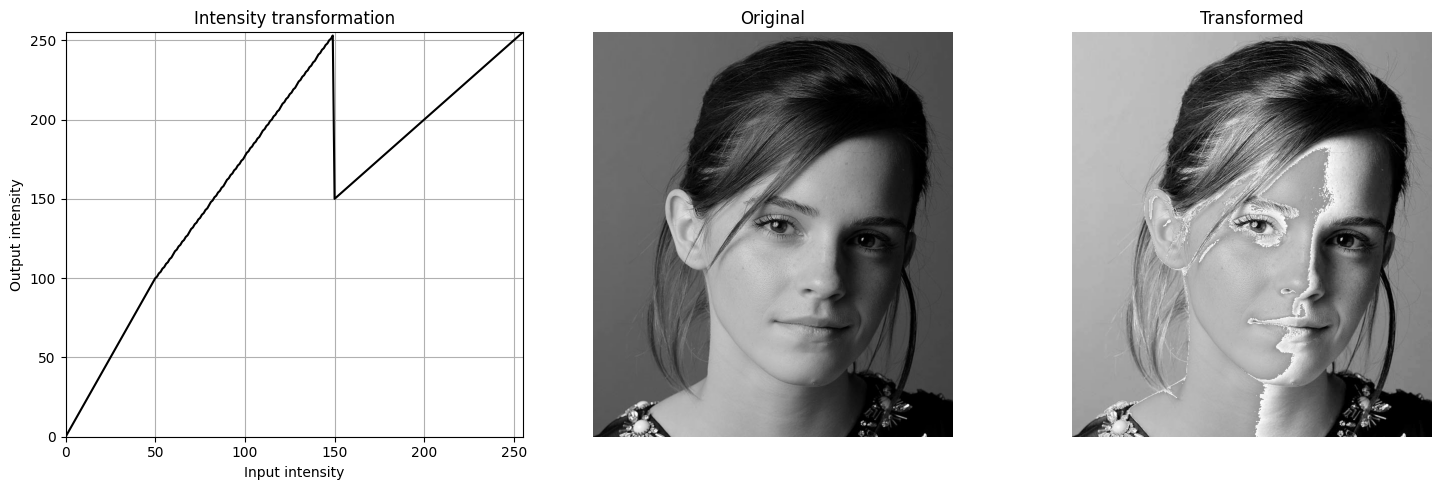

In [3]:
img = cv2.imread('images/emma.jpg', cv2.IMREAD_GRAYSCALE)

breakpoints = [[0, 0], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 2

### (a) Accentuating white matter

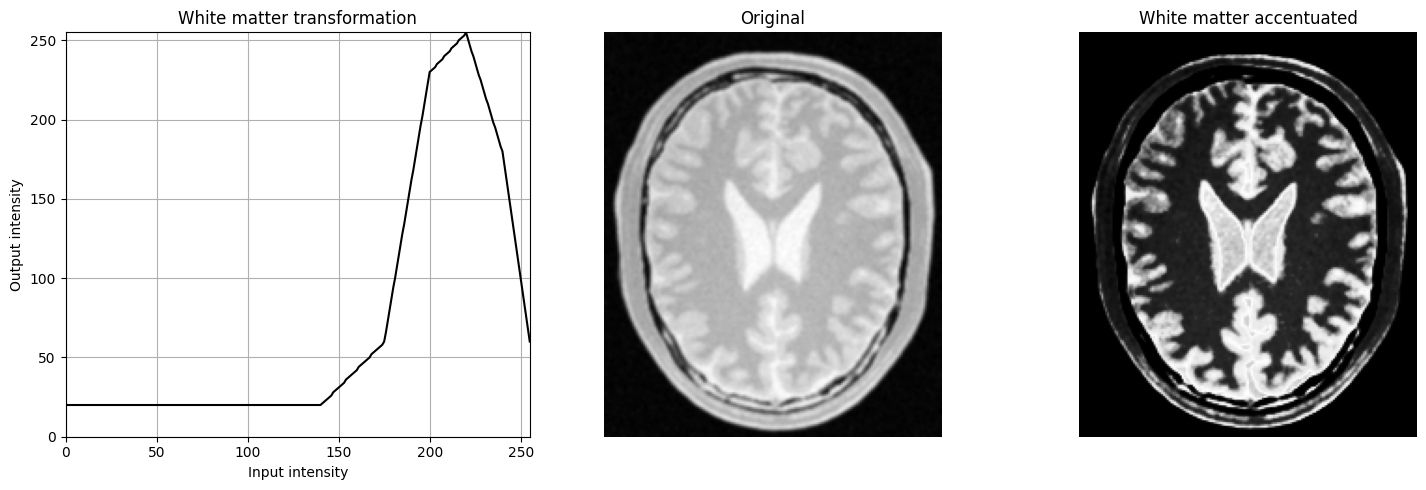

In [4]:
img2 = cv2.imread('images/brain_proton_density.jpeg', cv2.IMREAD_GRAYSCALE)
# A light blur first suppresses JPEG blockiness so the stretch below doesn't
# turn compression artifacts into visible noise.
img2 = cv2.GaussianBlur(img2, (3, 3), 0)

# White matter sits roughly in the 200-220 intensity band in this image.
# So we need a ramp that band up towards 255 while suppressing everything else.
white_bp = [[0, 20], [140, 20], [175, 60], [200, 230], [220, 255], [240, 180], [255, 60]]

# Reusing the same intensity_transform function from Q1
white_out, white_lut = intensity_transform(img2, white_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), white_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray')
axes[2].set_title('White matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Accentuating gray matter

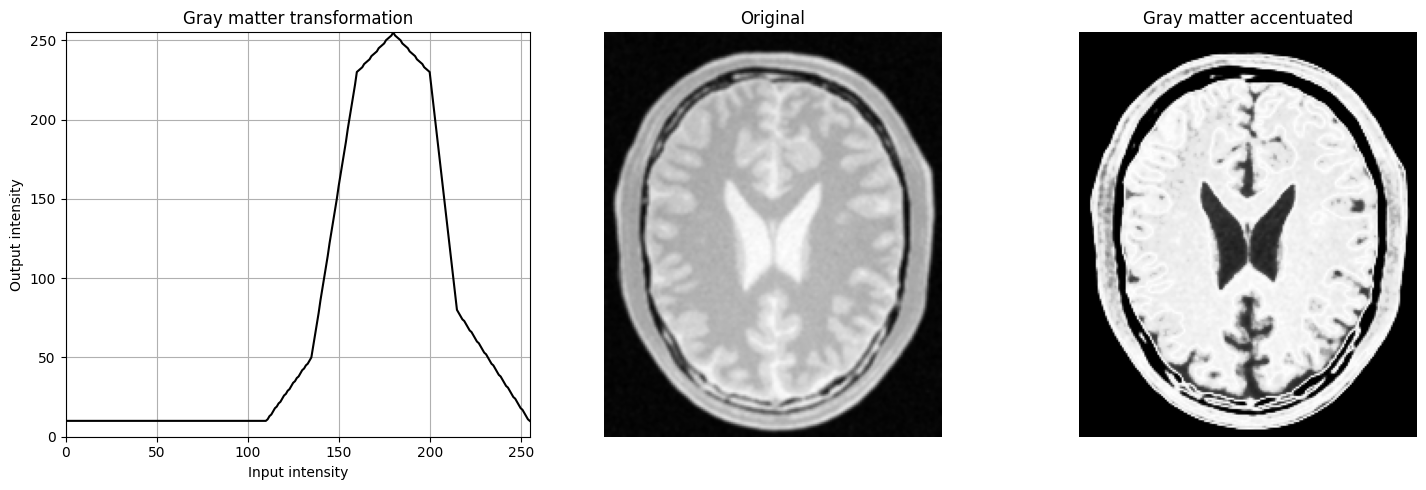

In [5]:
# Gray matter sits in a lower band (160-180), so we need to increase that
# while suppressing background, white matter, and the skull/scalp.
gray_bp = [[0, 10], [110, 10], [135, 50], [160, 230], [180, 255], [200, 230], [215, 80], [255, 10]]

gray_out, gray_lut = intensity_transform(img2, gray_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), gray_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 3

### (a) Gamma correction on the L plane in L*a*b* space

gamma = 0.5

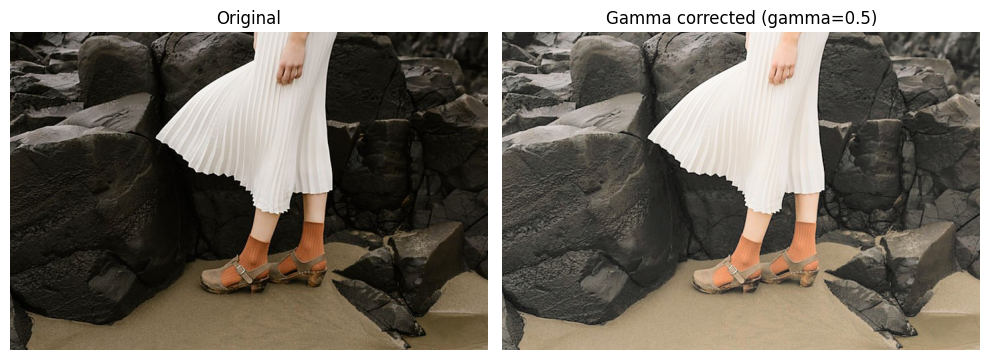

In [6]:
img3 = cv2.imread('images/gamma_correction.jpeg')
lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Most of the image (the rocks) is dark, so gamma < 1 lifts the shadows
gamma = 0.5
L_corrected = (255.0 * (L / 255.0) ** gamma).clip(0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_corrected, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (gamma={gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### (b) Histograms before and after correction

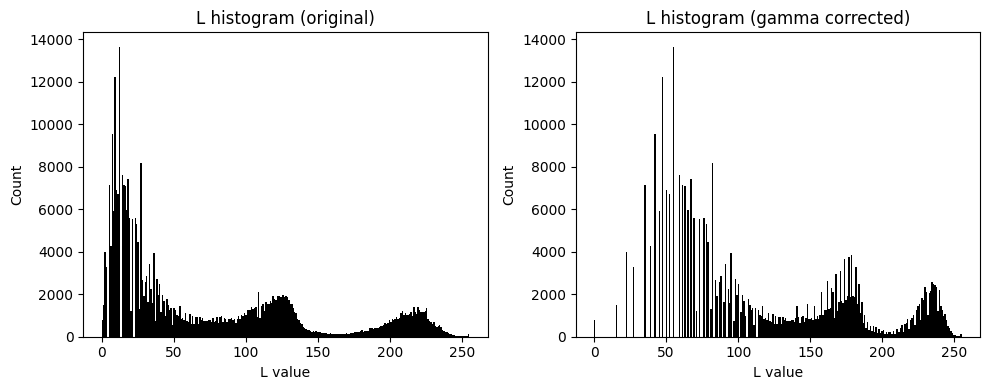

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(L.flatten(), bins=256, range=(0, 255), color='k')
axes[0].set_title('L histogram (original)')
axes[0].set_xlabel('L value')
axes[0].set_ylabel('Count')

axes[1].hist(L_corrected.flatten(), bins=256, range=(0, 255), color='k')
axes[1].set_title('L histogram (gamma corrected)')
axes[1].set_xlabel('L value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
